# 文件: chart_21_1.py

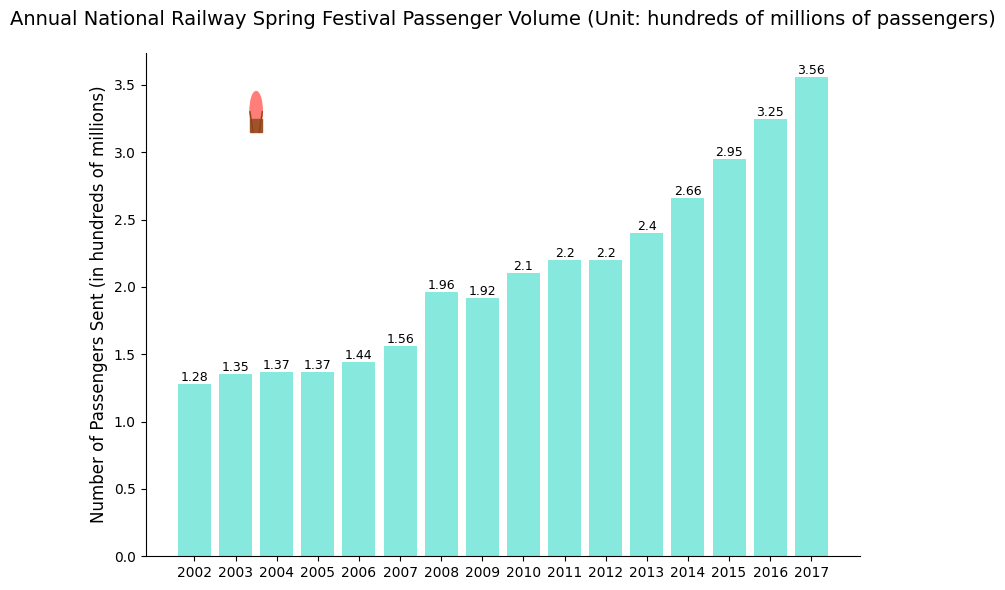

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Year data
years = np.arange(2002, 2018)
# Passenger volume data corresponding to each year (approximately close to the original data)
passenger_volumes = [1.28, 1.35, 1.37, 1.37, 1.44, 1.56, 
                     1.96, 1.92, 2.1, 2.2, 2.2, 2.4, 
                     2.66, 2.95, 3.25, 3.56]

# Create a figure
fig, ax = plt.subplots(figsize=(8, 6))

# Draw a bar chart, set the color to be close to the light green color scheme of the original chart
bar_rects = ax.bar(years, passenger_volumes, color='#87E8DE')

# Set x-axis ticks
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=10)

# Set y-axis label
ax.set_ylabel('Number of Passengers Sent (in hundreds of millions)', fontsize=12)
# Set the title
ax.set_title('Annual National Railway Spring Festival Passenger Volume (Unit: hundreds of millions of passengers)', fontsize=14, pad=20)

# Hide the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Label the values on the bars
for rect in bar_rects:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, f'{height}',
            ha='center', va='bottom', fontsize=9)

# Add some decorative elements, use pure graphics instead of pictures
hot_air_balloon = patches.Circle((2003.5, 3.3), 0.15, color='#FF7E79')
ax.add_patch(hot_air_balloon)

# Draw the basket and ropes of the hot air balloon
basket = patches.Rectangle((2003.35, 3.15), 0.3, 0.1, color='#A0522D')
ax.add_patch(basket)

# Draw the ropes
ax.plot([2003.35, 2003.425], [3.3, 3.15], color='#8B4513', linewidth=1)
ax.plot([2003.65, 2003.575], [3.3, 3.15], color='#8B4513', linewidth=1)

plt.tight_layout()
plt.show()

# 文件: chart_21_2.py

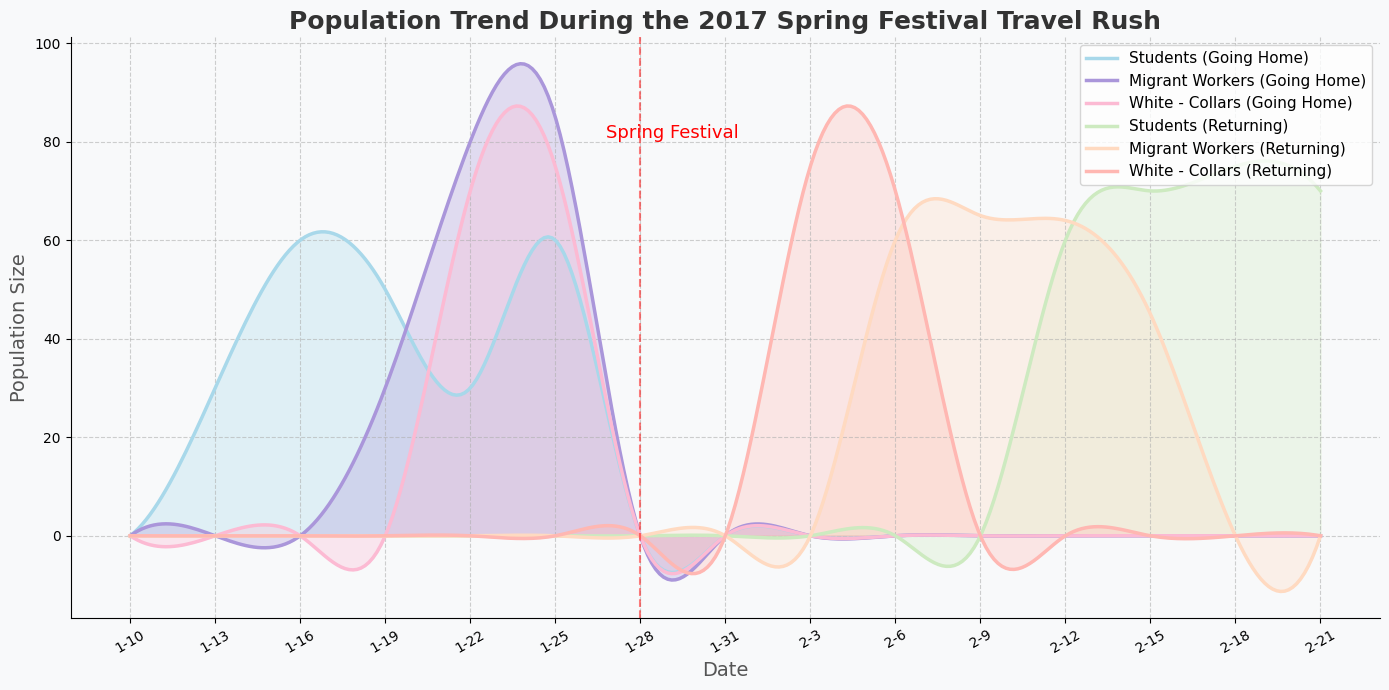

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Simulate original data (dates, population size)
dates = np.array(['1-10', '1-13', '1-16', '1-19', '1-22', '1-25', '1-28',
                  '1-31', '2-3', '2-6', '2-9', '2-12', '2-15', '2-18', '2-21'])

# Student going home data (peaks on 1-19 and 1-25, half - peak on 1-22, 0 on 1-10 and 2-21)
student_go = np.array([0, 30, 60, 50, 30, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Migrant worker going home data (peak around 1-25)
worker_go = np.array([0, 0, 0, 30, 80, 85, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# White - collar going home data (peak around 1-22)
white_collar_go = np.array([0, 0, 0, 0, 70, 75, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Return data (uniformly distributed in February)
student_back = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 70, 75, 70])
worker_back = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 65, 64, 45, 0, 0])
white_collar_back = np.array([0, 0, 0, 0, 0, 0, 0, 0, 75, 70, 0, 0, 0, 0, 0])

# 2. Create a uniformly distributed time axis
x_uniform = np.arange(len(dates))  # Uniformly distributed numerical axis

# 3. Interpolation and smoothing processing
def smooth_curve(y):
    x_new = np.linspace(x_uniform.min(), x_uniform.max(), 300)
    spline = make_interp_spline(x_uniform, y, k = 3)
    return x_new, spline(x_new)

# Smoothing process
x_smooth, student_go_smooth = smooth_curve(student_go)
_, worker_go_smooth = smooth_curve(worker_go)
_, white_collar_go_smooth = smooth_curve(white_collar_go)

_, student_back_smooth = smooth_curve(student_back)
_, worker_back_smooth = smooth_curve(worker_back)
_, white_collar_back_smooth = smooth_curve(white_collar_back)

# 4. Draw the curve graph
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

# Going home phase curve and filling
student_go_line, = ax.plot(x_smooth, student_go_smooth, color='#A8D8EA', linewidth=2.5, label='Students (Going Home)')
ax.fill_between(x_smooth, student_go_smooth, color='#A8D8EA', alpha=0.3)  # Fill the student going home curve

worker_go_line, = ax.plot(x_smooth, worker_go_smooth, color='#AA96DA', linewidth=2.5, label='Migrant Workers (Going Home)')
ax.fill_between(x_smooth, worker_go_smooth, color='#AA96DA', alpha=0.3)  # Fill the migrant worker going home curve

white_collar_go_line, = ax.plot(x_smooth, white_collar_go_smooth, color='#FCBAD3', linewidth=2.5, label='White - Collars (Going Home)')
ax.fill_between(x_smooth, white_collar_go_smooth, color='#FCBAD3', alpha=0.3)  # Fill the white - collar going home curve

# Return phase curve and filling
student_back_line, = ax.plot(x_smooth, student_back_smooth, color='#CDEAC0', linewidth=2.5, label='Students (Returning)')
ax.fill_between(x_smooth, student_back_smooth, color='#CDEAC0', alpha=0.3)  # Fill the student returning curve

worker_back_line, = ax.plot(x_smooth, worker_back_smooth, color='#FFDAC1', linewidth=2.5, label='Migrant Workers (Returning)')
ax.fill_between(x_smooth, worker_back_smooth, color='#FFDAC1', alpha=0.3)  # Fill the migrant worker returning curve

white_collar_back_line, = ax.plot(x_smooth, white_collar_back_smooth, color='#FFB7B2', linewidth=2.5, label='White - Collars (Returning)')
ax.fill_between(x_smooth, white_collar_back_smooth, color='#FFB7B2', alpha=0.3)  # Fill the white - collar returning curve

# 5. Set x - axis tick labels
plt.xticks(x_uniform, dates)
plt.xticks(rotation=30)

# 6. Add title, legend, and decoration
ax.set_title('Population Trend During the 2017 Spring Festival Travel Rush', fontsize=18, fontweight='bold', color='#333')
ax.set_xlabel('Date', fontsize=14, color='#555')
ax.set_ylabel('Population Size', fontsize=14, color='#555')
ax.legend(loc='upper right', fontsize=11)

# 7. Add a dividing line (Spring Festival position)
plt.axvline(x = 6.0, color='red', linestyle='--', alpha=0.5)
plt.text(5.6, max(student_go.max(), worker_go.max(), white_collar_go.max()) * 0.95,
         'Spring Festival', fontsize=13, color='red')

# 8. Add grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# 9. Hide the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 10. Display the chart
plt.tight_layout()
plt.show()

# 文件: chart_21_3.py

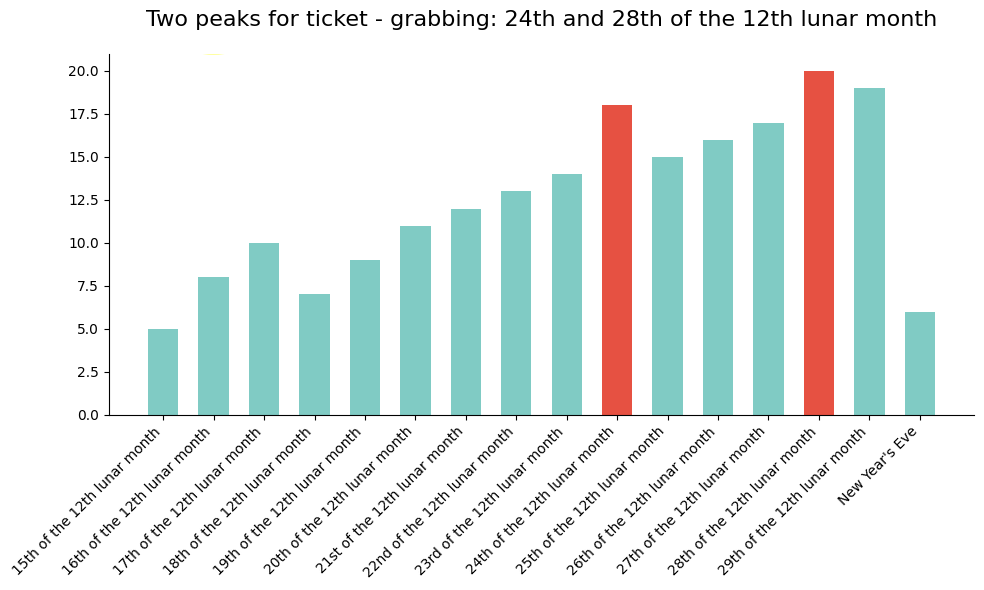

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Date labels
labels = ["15th of the 12th lunar month", "16th of the 12th lunar month", "17th of the 12th lunar month",
          "18th of the 12th lunar month", "19th of the 12th lunar month", "20th of the 12th lunar month",
          "21st of the 12th lunar month", "22nd of the 12th lunar month", "23rd of the 12th lunar month",
          "24th of the 12th lunar month", "25th of the 12th lunar month", "26th of the 12th lunar month",
          "27th of the 12th lunar month", "28th of the 12th lunar month", "29th of the 12th lunar month",
          "New Year's Eve"]
# Simulated data, generally showing a peak trend, can be fine - tuned according to actual situation
data = [5, 8, 10, 7, 9, 11, 12, 13, 14, 18, 15, 16, 17, 20, 19, 6]
# Index of peak dates (24th and 28th of the 12th lunar month, corresponding to indices 9 and 13 in the above labels)
peak_indices = [9, 13]

x = np.arange(len(labels))  # x - axis positions
width = 0.6  # Bar width

fig, ax = plt.subplots(figsize=(10, 6))  # Create a canvas and axes
# Draw the bar chart, most bars in one color, peak bars in another color
bars = []
for i in range(len(x)):
    if i in peak_indices:
        bar = ax.bar(x[i], data[i], width, color='#e65142')  # Peak color, similar to the red in the original chart
    else:
        bar = ax.bar(x[i], data[i], width, color='#80cbc4')  # Other bars' color, similar to the cyan - green in the original chart
    bars.append(bar)

# Set x - axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Set the title
ax.set_title('Two peaks for ticket - grabbing: 24th and 28th of the 12th lunar month', fontsize=16, pad=20)

# Hide the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add some decorative elements, simulating the small sun and clouds in the original chart (simply indicated, can be refined according to requirements)
import matplotlib.patches as patches
# Draw a small sun
sun = patches.Circle((1, max(data) + 2), radius=1, color='yellow', alpha=0.8)
ax.add_patch(sun)
# Draw clouds (simulated by simple rectangles, can be drawn more precisely)
cloud1 = patches.Rectangle((3, max(data) + 1.5), 2, 1, color='white', alpha=0.8)
cloud2 = patches.Rectangle((6, max(data) + 1), 2, 1, color='white', alpha=0.8)
ax.add_patch(cloud1)
ax.add_patch(cloud2)

plt.tight_layout()  # Automatically adjust the layout
plt.show()

# 文件: chart_21_4.py

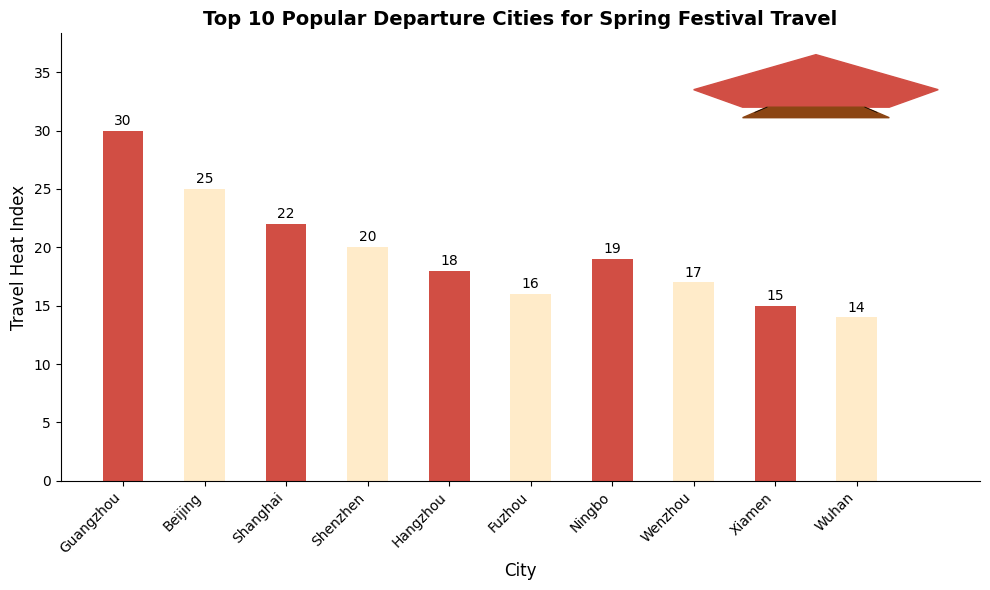

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# City names
cities = ["Guangzhou", "Beijing", "Shanghai", "Shenzhen", "Hangzhou", "Fuzhou", "Ningbo", "Wenzhou", "Xiamen", "Wuhan"]
# Simulated bar chart data, generally showing height differences, can be fine - tuned according to actual situation
data = [30, 25, 22, 20, 18, 16, 19, 17, 15, 14]

x = np.arange(len(cities))  # x-axis coordinates
width = 0.5  # Bar width

fig, ax = plt.subplots(figsize=(10, 6))  # Create a canvas and axis object, set the figure size
# Draw the bar chart, set the colors to two tones close to the original image, the rgb values can be fine - tuned to be closer
bars1 = ax.bar(x[::2], data[::2], width, color=(209/255, 78/255, 68/255))  # Red - series bars
bars2 = ax.bar(x[1::2], data[1::2], width, color=(255/255, 235/255, 201/255))  # Light beige bars

# Set x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=45, ha='right', fontsize=10)  # 倾斜45度并右对齐

# Set the chart title
ax.set_title("Top 10 Popular Departure Cities for Spring Festival Travel", fontsize=14, fontweight='bold')

# Add x-axis label
ax.set_xlabel("City", fontsize=12)
# Add y-axis label and unit
ax.set_ylabel("Travel Heat Index", fontsize=12)

# Hide the top and right axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add numerical labels above each bar
for i, v in enumerate(data):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)

# Use pure drawing methods to create decorative elements instead of images
from matplotlib.patches import Polygon, Circle

# Create a hot air balloon shape
def create_balloon(ax, x, y, scale=1.0):
    # Balloon body
    balloon = Polygon([
        (x, y+15*scale), (x-5*scale, y+5*scale), (x-3*scale, y), 
        (x+3*scale, y), (x+5*scale, y+5*scale), (x, y+15*scale)
    ], fill=True, color=(209/255, 78/255, 68/255))
    ax.add_patch(balloon)
    
    # Basket
    basket = Polygon([
        (x-2*scale, y), (x-3*scale, y-3*scale), 
        (x+3*scale, y-3*scale), (x+2*scale, y)
    ], fill=True, color=(139/255, 69/255, 19/255))
    ax.add_patch(basket)
    
    # Ropes
    ax.plot([x-2*scale, x-2.5*scale], [y, y-1.5*scale], 'k-', linewidth=0.5)
    ax.plot([x+2*scale, x+2.5*scale], [y, y-1.5*scale], 'k-', linewidth=0.5)

# Add a hot air balloon decoration in the upper right corner
create_balloon(ax, 8.5, 32, scale=0.3)

plt.tight_layout()  # Adjust the layout to ensure that the labels are not obscured
plt.show()

# 文件: chart_21_5.py

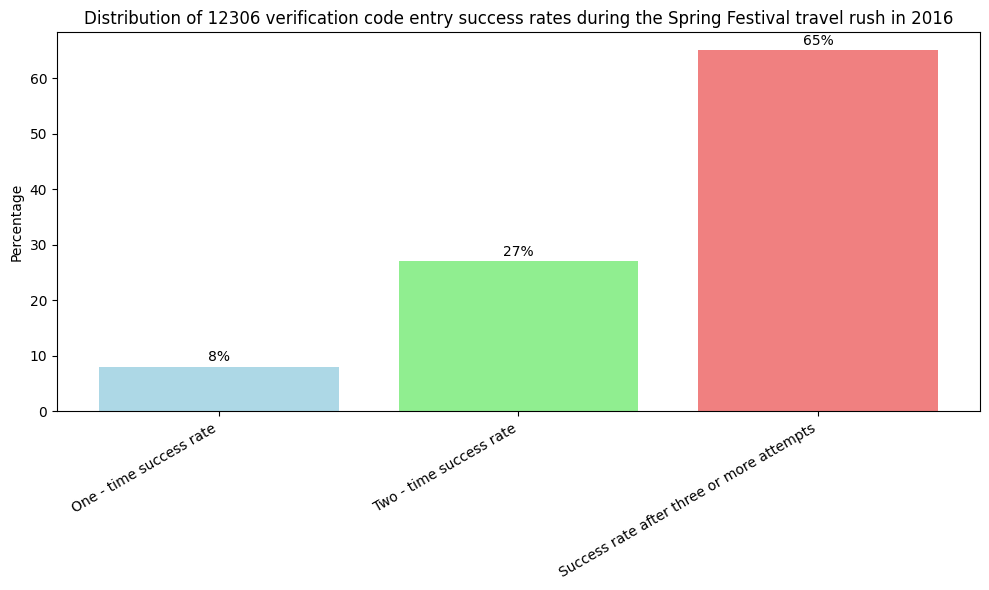

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['One - time success rate', 'Two - time success rate', 'Success rate after three or more attempts']
values = [8, 27, 65]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 6))  # 调整图表宽度

# Draw a bar chart
ax.bar(labels, values, color=['lightblue', 'lightgreen', 'lightcoral'])

# 设置x轴标签旋转45度
plt.xticks(rotation=30, ha='right', fontsize=10)  # 倾斜30度并右对齐

# Add numerical labels
for i, v in enumerate(values):
    ax.text(i, v + 1, f'{v}%', ha='center')

# Set the title and axis labels (adjust as needed)
ax.set_ylabel('Percentage')
# Add a title
ax.set_title('Distribution of 12306 verification code entry success rates during the Spring Festival travel rush in 2016')

# Display the figure
plt.tight_layout()  # 调整布局
plt.show()